# GeoSAR Example 01

# Flood Detection using Sentinel-1 SAR

This notebook demonstrates the complete GeoSAR flood detection workflow.

Workflow

Sentinel-1 Images

↓

SARImage

↓

detect_flood()

↓

Flood Mask

↓

Statistics

GeoSAR Version: 1.0.0

In [12]:
import os
import sys
module_path = os.path.abspath(os.path.expanduser("~/notebooks/geospatial/"))
# print(f"Module path is {module_path}")
# print(f"Sys path is {sys.path}")
if module_path not in sys.path:
    print("$$$$$$$$")
    sys.path.append(module_path)
import sar
import matplotlib.pyplot as plt

from sar import (
    detect_flood,
)
from sar.sar_radiometry import db_to_linear
from sar.sar_io import load_sar
from sar.sar_operations import copy_image,create_empty_like,align_to_reference,difference

In [23]:
PRE_IMAGE = "/home/ubuntu/notebooks/geospatial/sample_image_preflood1.tif"

POST_IMAGE = "/home/ubuntu/notebooks/geospatial/sample_image_postflood1.tif"

pre = load_sar(PRE_IMAGE)

post = load_sar(POST_IMAGE)

#empty = create_empty_like(pre)

aligned_post = align_to_reference(pre,post)

pre_linear = db_to_linear(pre)

post_linear = db_to_linear(aligned_post)

In [15]:
pre = pre_linear
post = post_linear

Best index: 151
Threshold : -1.080517447638465


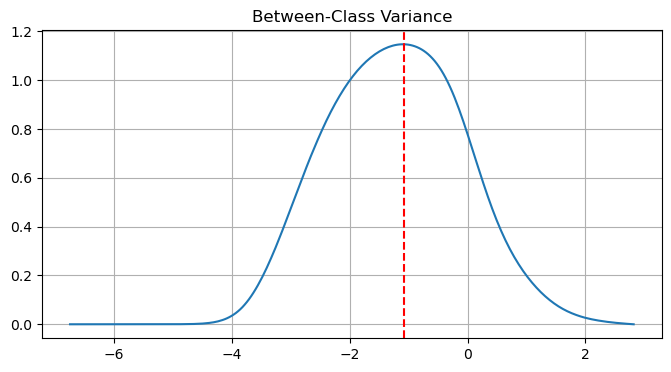

image.data dtype : uint8
image.data shape : (5608, 5071)
structure dtype  : bool
structure shape  : (3, 3)
iterations       : 1
bool


In [16]:
flood = detect_flood(
    pre,
    post,
)

In [17]:
print(flood.statistics())

print(
    "Flood Pixels:",
    int(flood.data.sum())
)

{'minimum': 0.0, 'maximum': 1.0, 'mean': 0.26581218305161153, 'std': 0.4417647183659513, 'valid_pixels': 15367644, 'nodata_pixels': 13070524}
Flood Pixels: 4084999


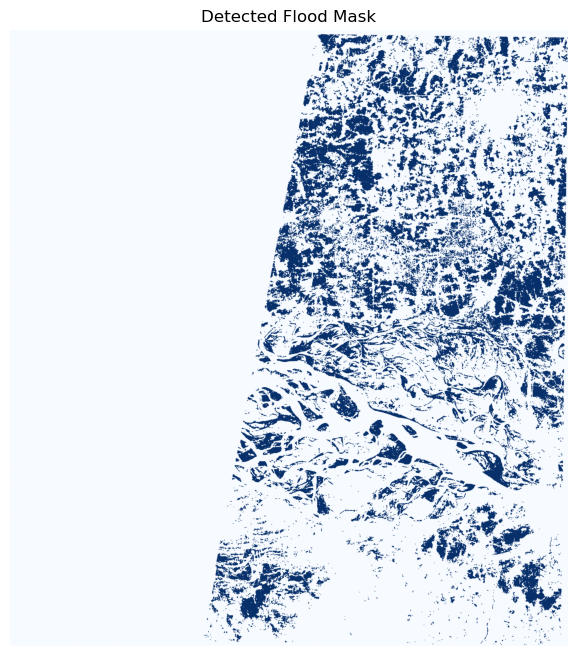

In [18]:
plt.figure(figsize=(8,8))

plt.imshow(
    flood.data,
    cmap="Blues",
)

plt.title("Detected Flood Mask")

plt.axis("off")

plt.show()

In [19]:
valid_pixels = flood.statistics()["valid_pixels"]

flood_pixels = int(flood.data.sum())

percentage = (
    flood_pixels / valid_pixels
) * 100

print(f"Flood Percentage : {percentage:.2f}%")

Flood Percentage : 26.58%


In [21]:
print("Processing History")

for step in flood.provenance:
    print("-", step)

Processing History


AttributeError: 'SARImage' object has no attribute 'provenance'

In [ ]:
## Summary

The GeoSAR flood detection workflow completed successfully.

Pipeline

- Radiometric Conversion
- Speckle Filtering
- Log-Ratio Change Detection
- Otsu Thresholding
- Binary Morphology
- Small Object Removal

using a single function:

```python
detect_flood(pre, post)
```

This notebook demonstrates the standard workflow for GeoSAR Version 1.0.